In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from pathlib import Path
from itertools import product

import seaborn as sns

In [4]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn351759',
r'sn030151_vn301508',
r'sn030151_vn251256',
r'sn030151_vn201005',
r'sn030151_vn150754',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v150754',
r'sn030151_v201005',
r'sn030151_v251256',
r'sn030151_v301508',
r'sn030151_v351759',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn351759',
r'sn020101_vn301508',
r'sn020101_vn251256',
r'sn020101_vn201005',
r'sn020101_vn150754',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v150754',
r'sn020101_v201005',
r'sn020101_v251256',
r'sn020101_v301508',
r'sn020101_v351759',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn351759',
r'sn010050_vn301508',
r'sn010050_vn251256',
r'sn010050_vn201005',
r'sn010050_vn150754',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v150754',
r'sn010050_v201005',
r'sn010050_v251256',
r'sn010050_v301508',
r'sn010050_v351759',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn351759',
r's000000_vn301508',
r's000000_vn251256',
r's000000_vn201005',
r's000000_vn150754',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v150754',
r's000000_v201005',
r's000000_v251256',
r's000000_v301508',
r's000000_v351759',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn351759',
r's010050_vn301508',
r's010050_vn251256',
r's010050_vn201005',
r's010050_vn150754',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v150754',
r's010050_v201005',
r's010050_v251256',
r's010050_v301508',
r's010050_v351759',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn351759',
r's020101_vn301508',
r's020101_vn251256',
r's020101_vn201005',
r's020101_vn150754',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v150754',
r's020101_v201005',
r's020101_v251256',
r's020101_v301508',
r's020101_v351759',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn351759',
r's030151_vn301508',
r's030151_vn251256',
r's030151_vn201005',
r's030151_vn150754',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v150754',
r's030151_v201005',
r's030151_v251256',
r's030151_v301508',
r's030151_v351759',
r's030151_v402010',
]

In [7]:
casenames = [
r's000000_v000000',
]

In [8]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/'+casenames[count]+'_lite.npz')))

In [9]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [ ]:
def rotor_average(f, r, theta):
    dr = np.gradient(r)
    dtheta = np.gradient(theta)

    area_elements = np.outer(dr * r, dtheta)
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)

    area_avg = np.sum(integrand) / A

    return area_avg

In [ ]:
def annulus_average(f, theta):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(f * weights, axis=1)

    return area_avg

In [11]:
wrfles_bem[0]['radius']

array(99.5)

In [10]:
t = np.linspace(0,2*np.pi,wrfles_bem[0]['Nsct'])
r = np.linspace(0,1,wrfles_bem[0]['Nelm'])

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['radius'] + 378

wrf_ind   = np.zeros(len(coords), dtype=float)
wrf_cot   = np.zeros(len(coords), dtype=float)

wrf_tsr   = np.zeros(len(coords), dtype=float)
wrf_omg   = np.zeros(len(coords), dtype=float)

wrf_cax   = np.zeros(len(coords), dtype=float)
wrf_vax   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
wrf_vtn   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

wrf_rel   = np.zeros(len(coords), dtype=float)

wrf_CL    = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
wrf_CD    = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

wrf_L    = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
wrf_D    = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

wrf_phi    = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

wrf_pow   = np.zeros(len(coords), dtype=float)
wrf_thr   = np.zeros(len(coords), dtype=float)

U_loc     = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
dir_loc   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

u     = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
v     = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))
wrf_W     = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(coords)))

shapiro   = np.zeros(len(coords), dtype=float)

Uhub     = np.zeros(len(coords), dtype=float)

profiles = np.zeros((400, len(coords)))
profiles_u = np.zeros((400, len(coords)))

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles_bem[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    full_z = np.linspace(0,756,400)

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # u_inf = u_func(full_z)
    # v_inf = v_func(full_z)

    # profiles[:,count] = v_inf
    # profiles_u[:,count] = u_inf

    # Background wind speed
    U = np.sqrt(u_inf**2 + v_inf**2)

    # Background wind direction
    wdir = np.atan2(v_inf,u_inf)

    # Radial coordinates
    # r = np.linspace(0.0001, 0.99999, 26) * R
    # mu = np.linspace(0.0001, 0.99999, 26)
    # r =  (np.ones_like(wdir) * r).T

    # r = wrfles_bem[count]['rOverR'] * R
    r = wrfles_bem[count]['rOverR']
    r_mat =  (np.ones_like(wdir) * r).T
    mu = wrfles_bem[count]['rOverR']

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(378)**2 + v_func(378)**2)

    # Compute induction
    # a_save = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / U_hub
    a_save = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / U_hub
    a = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / U_hub

    # a_bar = 1/(2 * np.pi) * np.trapezoid(2 * np.trapezoid(a.T * mu, mu), theta, axis=-1)
    a_bar = annulus_average(a,mu,theta)
    a_bar_save = annulus_average(a,mu,theta)


    # a_bar_save = 1/(2 * np.pi) * np.trapezoid(2 * np.trapezoid(a_save.T * mu, mu), theta, axis=-1)

    # Compute inflow angle, lift, and drag coefficients
    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    # Radial chord lengths
    chord = [4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734]
    
    twist = [11.9985400,12.0084000,11.7778500,10.5644900,8.6145420,6.8761240,5.7328380,4.9626800,4.3324590,3.7594000,3.2026710,2.6119980,1.9676750,1.2843650,0.5830396,-0.1154623,-0.7903028,-1.4215150,-1.9910930,-2.4710830,-2.8354060,-3.0636580,-3.0786780,-2.7138780,-1.5452120,-1.0416400]
    
    chord =  (np.ones_like(Cd.T) * chord).T

    # Local solidity
    # sigma = (3 * chord) / (2 * np.pi * r)
    sigma = (3 * chord) / (2 * np.pi * r_mat * 99.5)

    # Tip speed ratio
    tsr = np.mean(wrfles_bem[count]['omega']*R*2*np.pi/(U_hub*60), axis=0) 

    aprime=0

    local_yaw = wdir.T

    Vax = (
        U.T/U_hub
        * (1 - a_bar.T)
        * np.cos(local_yaw * np.cos(theta))
        * np.cos(local_yaw * np.sin(theta))
    )
    Vtan = (
        (1 + aprime) * tsr * r_mat
        # (1 + aprime) * tsr * r/R
        - U.T/U_hub * (1 - a_bar.T)
        * np.cos(local_yaw * np.sin(theta))
        * np.sin(local_yaw * np.cos(theta))
    )

    W = np.sqrt(Vax**2 + Vtan**2)

    # phi = np.atan2(Vax,Vtan)

    # W = np.mean(wrfles_bem[count]['vrel'], axis=0)/U_hub

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    u[:,:,count] = np.mean(wrfles_bem[count]['u'], axis=0)
    v[:,:,count] = np.mean(wrfles_bem[count]['v'], axis=0)

    U_loc[:,:,count]   = U.T/U_hub
    dir_loc[:,:,count] = wdir.T

    wrf_L[:,:,count]  = np.mean(wrfles_bem[count]['l'], axis=0)
    wrf_D[:,:,count]  = np.mean(wrfles_bem[count]['d'], axis=0)
    wrf_CL[:,:,count]  = np.mean(wrfles_bem[count]['cl'], axis=0)
    wrf_CD[:,:,count]  = np.mean(wrfles_bem[count]['cd'], axis=0)
    wrf_phi[:,:,count]  = phi
    Uhub[count]        = U_hub
    wrf_W[:,:,count]     = np.mean(wrfles_bem[count]['vrel'], axis=0)
    wrf_rel[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(W, theta, axis=-1) * mu, mu)
    # wrf_vax[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Vax, theta, axis=-1) * mu, mu)
    # wrf_vtn[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Vtan, theta, axis=-1) * mu, mu)
    wrf_vax[:,:,count]   = Vax
    wrf_vtn[:,:,count]  = Vtan

    wrf_cax[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Cax, theta, axis=-1) * mu, mu)
    # wrf_cot[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(ct, theta, axis=-1) * mu, mu)
    # wrf_rel[count]     = annulus_average(W,r,theta)
    # wrf_vax[count]     = annulus_average(Vax,r,theta)
    # wrf_vtn[count]     = annulus_average(Vtan,r,theta)
    # wrf_cax[count]     = annulus_average(Cax,r,theta)
    # wrf_cot[count]     = annulus_average(ct,r,theta)
    wrf_cot[count]     = annulus_average(ct,mu,theta)
    wrf_ind[count]     = a_bar_save
    wrf_thr[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
    wrf_pow[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
    shapiro[count]     = wrfles_bem[count]['shapiroM'][1]
    wrf_tsr[count]     = tsr
    wrf_omg[count]     = np.mean(wrfles_bem[count]['omega'], axis=0) 


# END LOOP

np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_v.npy',   v)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_u.npy',   u)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_L.npy', wrf_L)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_D.npy', wrf_D)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CL.npy', wrf_CL)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CD.npy', wrf_CD)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_phi.npy', wrf_phi)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_W.npy', wrf_W)


np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy',casenames)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy',   U_loc)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy', dir_loc)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy',    Uhub)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy', wrf_rel)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy', wrf_vax)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy', wrf_vtn)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy', wrf_cax)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy', wrf_cot)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy', wrf_ind)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy', wrf_thr)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy', wrf_pow)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy', shapiro)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy', wrf_tsr)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy', shapiro)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy', wrf_tsr)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy', wrf_omg)
np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz", Nsct=wrfles_bem[0]['Nsct'], Nelm=wrfles_bem[0]['Nelm'], rOverR=wrfles_bem[0]['rOverR'], R = R)

/tmp/ipykernel_3118045/3723695538.py:177: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_thr[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
/tmp/ipykernel_3118045/3723695538.py:178: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_pow[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
/tmp/ipykernel_3118045/3723695538.py:179: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shapiro[count]     = wrfles_bem[count]['shapiroM'][1]
/tmp/ipykernel_

In [14]:
np.linspace(0.0001, 0.99999, 26)

array([1.000000e-04, 4.009560e-02, 8.009120e-02, 1.200868e-01,
       1.600824e-01, 2.000780e-01, 2.400736e-01, 2.800692e-01,
       3.200648e-01, 3.600604e-01, 4.000560e-01, 4.400516e-01,
       4.800472e-01, 5.200428e-01, 5.600384e-01, 6.000340e-01,
       6.400296e-01, 6.800252e-01, 7.200208e-01, 7.600164e-01,
       8.000120e-01, 8.400076e-01, 8.800032e-01, 9.199988e-01,
       9.599944e-01, 9.999900e-01])

In [21]:
wrfles_bem[count].keys()

dict_keys(['diameter', 'radius', 'hub_diameter', 'hub_radius', 'hub_height', 'rOverR', 'dx', 'dy', 'dz', 'dt', 'Nx', 'Ny', 'Nz', 'tower_xloc', 'tower_yloc', 'Nsct', 'Nelm', 'uinf', 'omega', 'thrust', 'power_aero', 'power_mech', 'power_gen', 'torque_aero', 'ct', 'cp', 'v0', 'f', 'fn', 'ft', 'l', 'd', 'cl', 'cd', 'aoa', 'v1', 'u', 'v', 'w', 'v_tan', 'vrel', 'phi', 'bpx', 'bpy', 'bpz', 'shapiroM'])

In [17]:
r = wrfles_bem[count]['rOverR']

theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

annulus_average(W, r, theta)

np.float64(6.116923121654715)

In [12]:
Uhub

array([7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.02,
       7.02, 7.02, 7.02, 7.02, 7.02, 7.02, 7.01, 7.01, 7.01, 7.01, 7.01,
       7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01,
       7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01,
       7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.01, 7.  , 7.  , 7.  , 7.  ,
       7.  , 7.  , 7.  , 7.  , 7.  , 7.  , 7.  , 7.  , 7.  , 7.  , 7.  ,
       7.  , 7.  , 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99,
       6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99,
       6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99, 6.99,
       6.99, 6.99, 6.99, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98,
       6.98, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98, 6.98])

In [14]:
wrf_tsr

array([9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.05343916, 9.05343916,
       9.05343916, 9.05343916, 9.05343916, 9.05343916, 9.05343

In [15]:
wrf_omg

array([6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004, 6.0735004,
       6.0735004, 6.0735004, 6.0735004, 6.0735004, 

/tmp/ipykernel_1115252/4058135251.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)


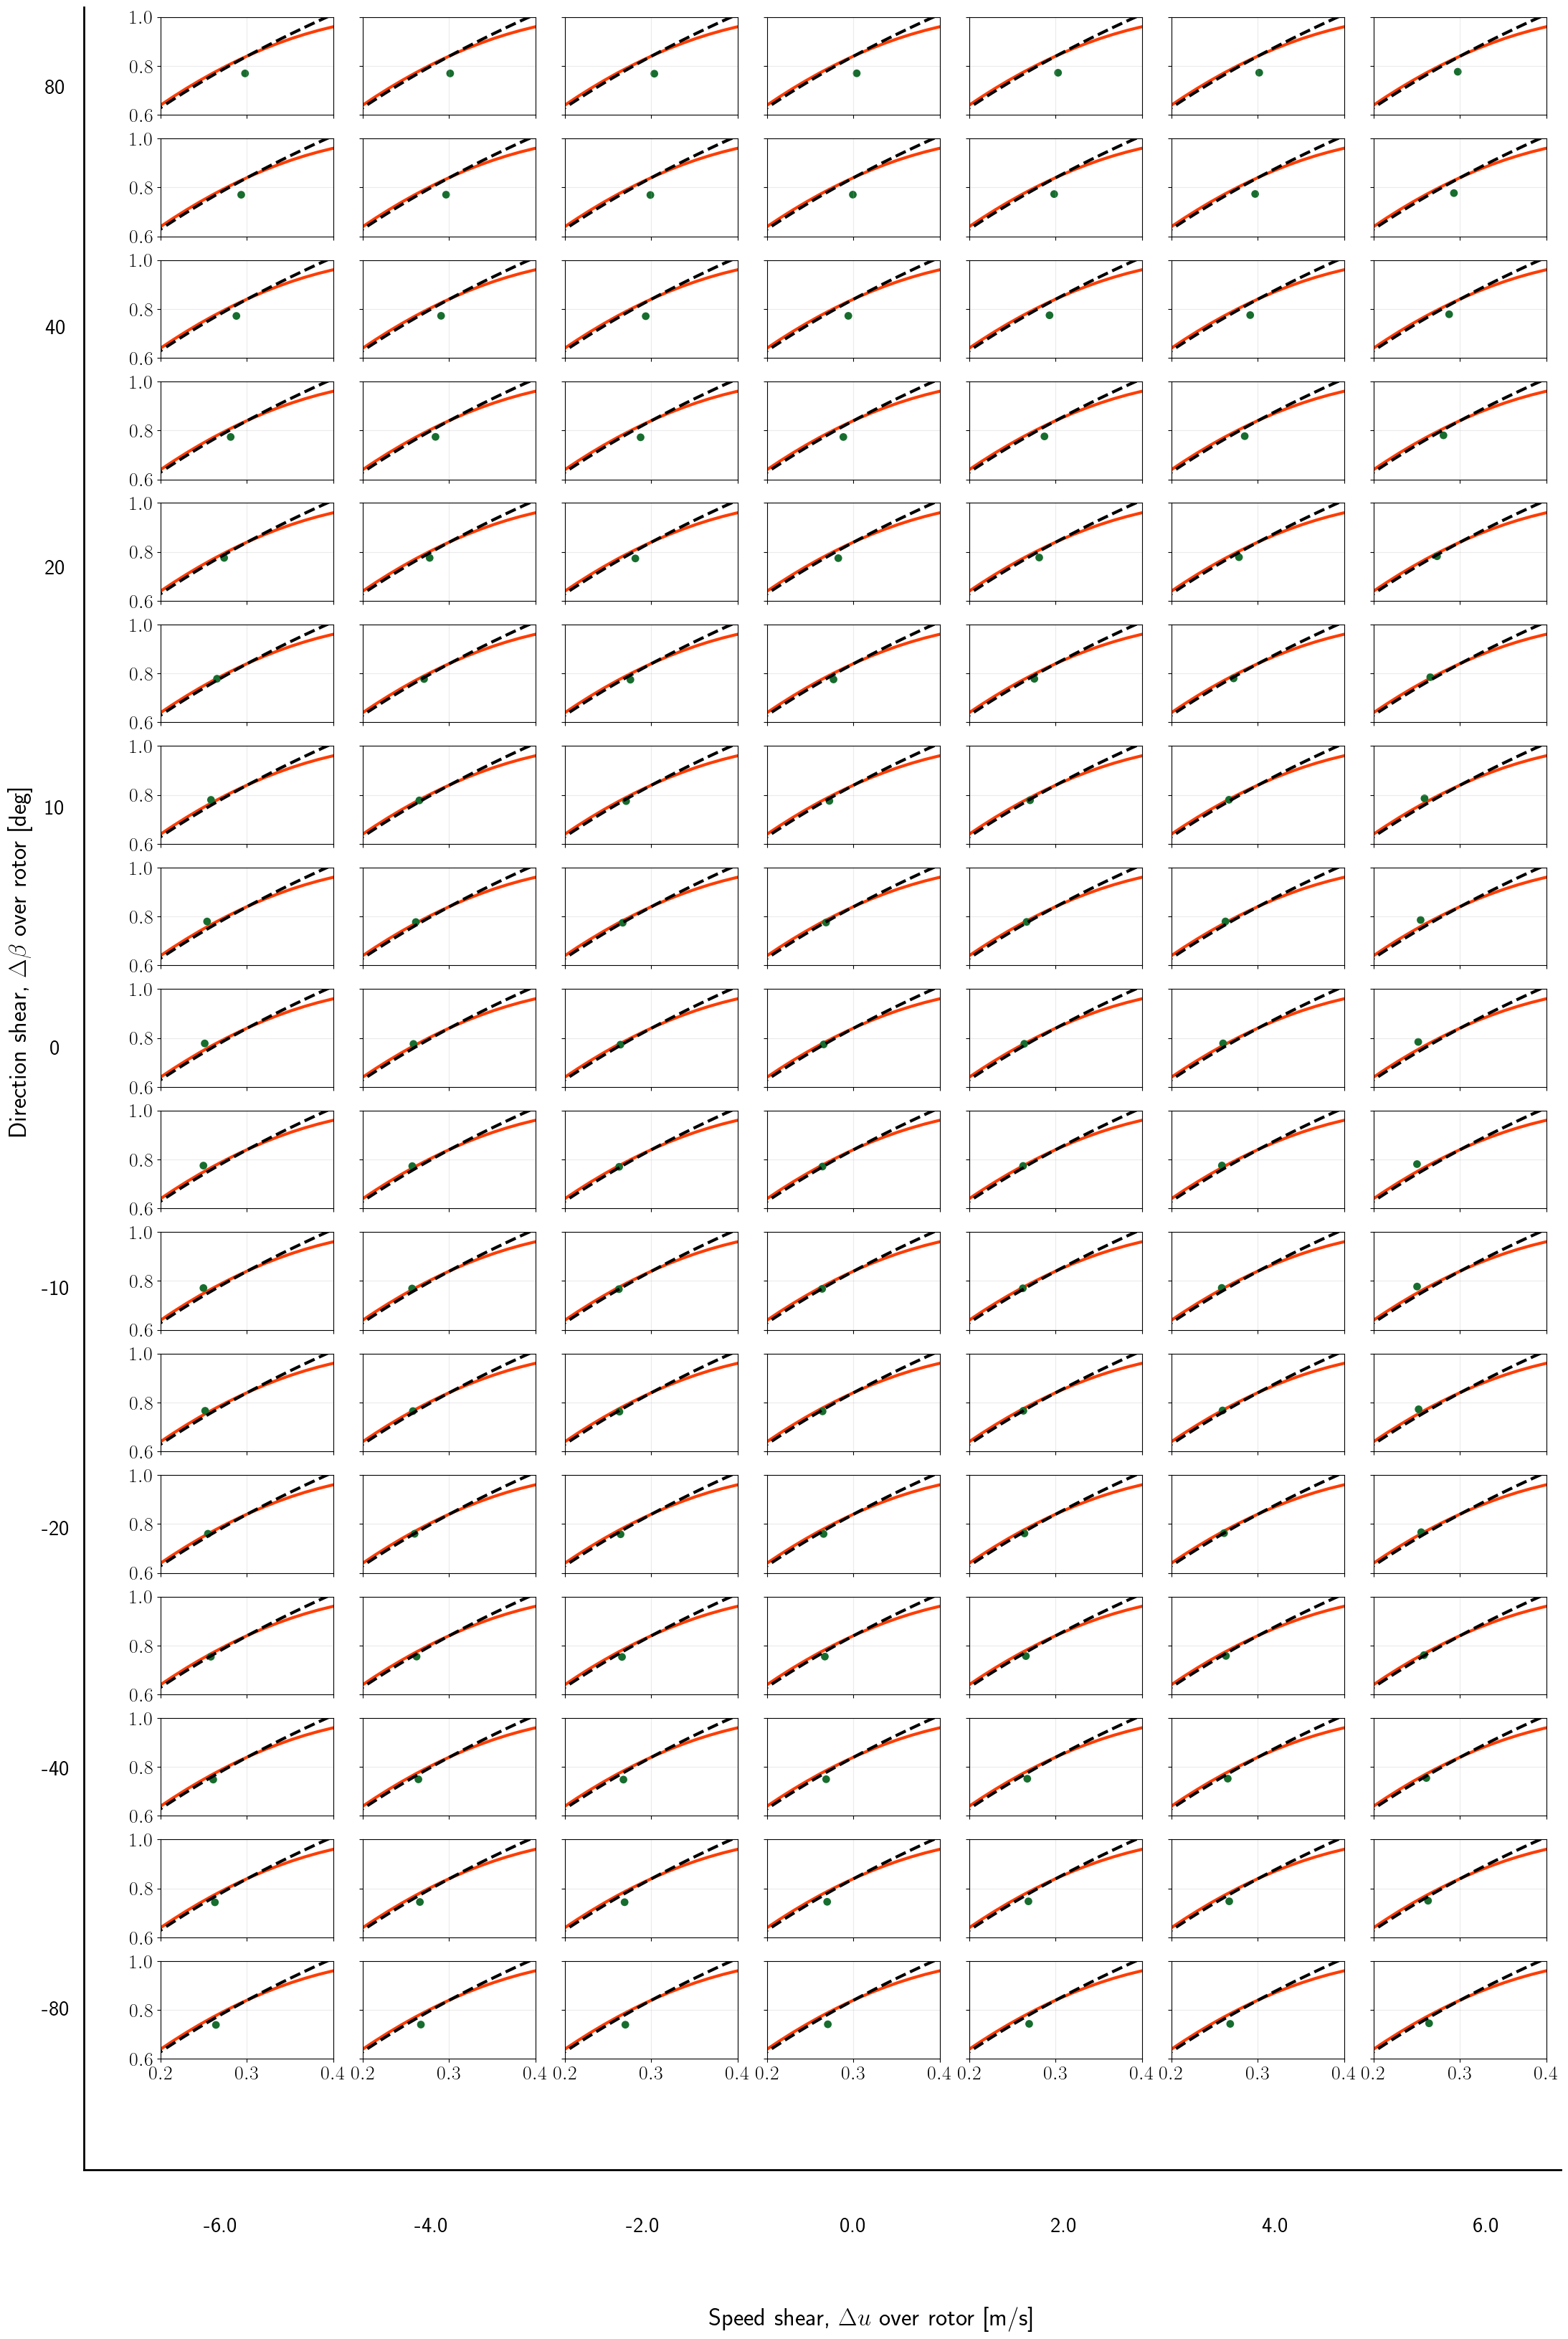

In [10]:
# Plot rotor

x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

fig, ax = plt.subplots(nrows=17, ncols=7, figsize=(20, 29), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)

    ax[coords[count][1],coords[count][0]].grid(True, alpha=0.25)

    ax[coords[count][1],coords[count][0]].set_xlim([0.2,0.4])
    ax[coords[count][1],coords[count][0]].set_ylim([0.6,1.0])



line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=25,rotation=90)

plt.show()

/tmp/ipykernel_1115252/3061423831.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)
/tmp/ipykernel_1115252/3061423831.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels())
/tmp/ipykernel_1115252/3061423831.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)
/tmp/ipykernel_1115252/3061423831.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_ytickl

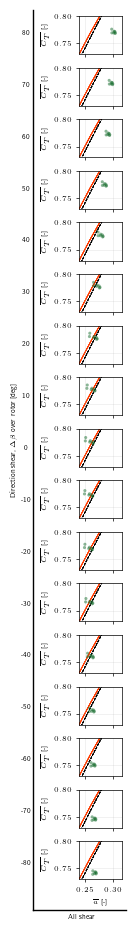

In [14]:
# Plot rotor

x_temp_vert = [0,0,0,0,0,0,0]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

fig, ax = plt.subplots(nrows=17, ncols=1, figsize=(0.9, 9), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1]].plot(a_mom, ct_mom, '#ff3c00',linewidth=0.5,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1]].plot(a_mad, ct_mad, 'k--',linewidth=0.5,zorder=2)

    mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)

    ax[coords[count][1]].set_xlim([0.24,0.315])
    ax[coords[count][1]].set_ylim([0.73,0.80])

    for label in ax[coords[count][1]].get_xticklabels():
        label.set_fontsize(5)
    for label in ax[coords[count][1]].get_yticklabels():
        label.set_fontsize(5)
    for spine in ax[coords[count][1]].spines.values():
        spine.set_linewidth(0.5)

    ax[coords[count][1]].tick_params(width=0.5, length=2)

    ax[coords[count][1]].grid(True, alpha=0.25, linewidth=0.5)

    ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels())

    ax[coords[count][1]].set_ylabel('$\overline{C_T}$ [-]', fontsize = 5)

ax[-1].set_xlabel('$\overline{a}$ [-]', fontsize = 5)

line_y = 0.0  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=1)
])

# # Add text to the number line
# positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
# labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = 0.0, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=1)
])

# # Add text to the number line
positions = np.linspace(0.05,1.03, 18)  # Adjust the number of points and spacing
labels = ['-80', '-70', '-60', '-50', '-40', '-30', '-20', '-10', '0', '10', '20', '30', '40', '50', '60', '70', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_x-0.08,pos, label, ha='center', fontsize=5)

# # Add a title for the number line
fig.text(-0.25,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=5,rotation=90)
fig.text(0.5,-0.01, 'All shear', ha='center', fontsize=5)

plt.savefig(f"./figure.png", bbox_inches="tight", dpi=600)

plt.show()

In [10]:
wrf_tsr

array([9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.01474925, 9.01474925, 9.01474925,
       9.01474925, 9.01474925, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.02760909, 9.02760909, 9.02760909, 9.02760909,
       9.02760909, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.04050568, 9.04050568,
       9.04050568, 9.04050568, 9.04050568, 9.05343916, 9.05343916,
       9.05343916, 9.05343916, 9.05343916, 9.05343916, 9.05343

In [11]:
0.32/9

0.035555555555555556

In [13]:
np.mean(wrfles_bem[count]['u'], axis=0)

array([[6.8604374, 6.862154 , 6.86359  , ..., 6.8536787, 6.8561945,
        6.85845  ],
       [6.850529 , 6.8509593, 6.851282 , ..., 6.848421 , 6.8492765,
        6.849975 ],
       [6.482593 , 6.47564  , 6.4701457, ..., 6.5110493, 6.5004163,
        6.4908915],
       ...,
       [7.9591827, 7.8131986, 7.777965 , ..., 7.967867 , 7.9298353,
        7.890243 ],
       [8.375616 , 8.336961 , 8.304878 , ..., 8.525255 , 8.474008 ,
        8.422444 ],
       [9.001532 , 8.957707 , 8.90637  , ..., 9.085482 , 9.0646715,
        9.037214 ]], shape=(26, 158), dtype=float32)

In [14]:
np.mean(wrfles_bem[count]['v'], axis=0)

array([[-0.16662502, -0.27482426, -0.26190478, ..., -0.18416803,
        -0.17891523, -0.17306346],
       [-0.22229156, -0.3132927 , -0.29390377, ..., -0.24998972,
        -0.24119447, -0.23196481],
       [ 0.08937852,  0.06512886,  0.08060159, ...,  0.04730956,
         0.06237123,  0.07638999],
       ...,
       [-3.0627978 , -3.104824  , -3.1550949 , ..., -2.8732824 ,
        -2.9343219 , -2.9923894 ],
       [-3.2493095 , -3.3019903 , -3.352623  , ..., -3.0712335 ,
        -3.1316721 , -3.188805  ],
       [-3.4570448 , -3.508814  , -3.5568516 , ..., -3.278294  ,
        -3.3390698 , -3.3968184 ]], shape=(26, 158), dtype=float32)

In [26]:
wrfles_bem[0]['hub_radius']

array(2.4)

In [18]:
wrfles_bem[0]['hub_diameter']/2

np.float64(2.4)

In [17]:
wrfles_bem[0].keys()

dict_keys(['diameter', 'radius', 'hub_diameter', 'hub_radius', 'hub_height', 'rOverR', 'dx', 'dy', 'dz', 'dt', 'Nx', 'Ny', 'Nz', 'tower_xloc', 'tower_yloc', 'Nsct', 'Nelm', 'uinf', 'omega', 'thrust', 'power_aero', 'power_mech', 'power_gen', 'torque_aero', 'ct', 'cp', 'v0', 'f', 'fn', 'ft', 'l', 'd', 'cl', 'cd', 'aoa', 'v1', 'u', 'v', 'w', 'v_tan', 'vrel', 'phi', 'bpx', 'bpy', 'bpz', 'shapiroM'])

In [17]:
np.mean(wrfles_bem[count]['thrust'], axis=0)

array([714794.2], dtype=float32)

In [22]:
np.mean(wrfles_bem[count]['thrust'], axis=0)

array([714829.8], dtype=float32)

In [35]:
colors = sns.dark_palette("#69d", 4)

In [34]:
sns.dark_palette("#69d", 4)[::-1]

[(np.float64(0.4), np.float64(0.6), np.float64(0.8666666666666667)),
 (np.float64(0.3137166044882655),
  np.float64(0.4493648793461167),
  np.float64(0.6318257175920923)),
 (np.float64(0.227433208976531),
  np.float64(0.2987297586922334),
  np.float64(0.39698476851751796)),
 (np.float64(0.1411498134647965),
  np.float64(0.14809463803835013),
  np.float64(0.1621438194429436))]

In [36]:
colors_v = colors[::-1] + colors[1::]

In [ ]:
purp = sns.cubehelix_palette(9)

In [39]:
styles = [r'-.',r'-.',r'-.',r'-',r'--',r'--',r'--']

Text(0.5, 0, '$U/U_{\\infty}$ [-]')

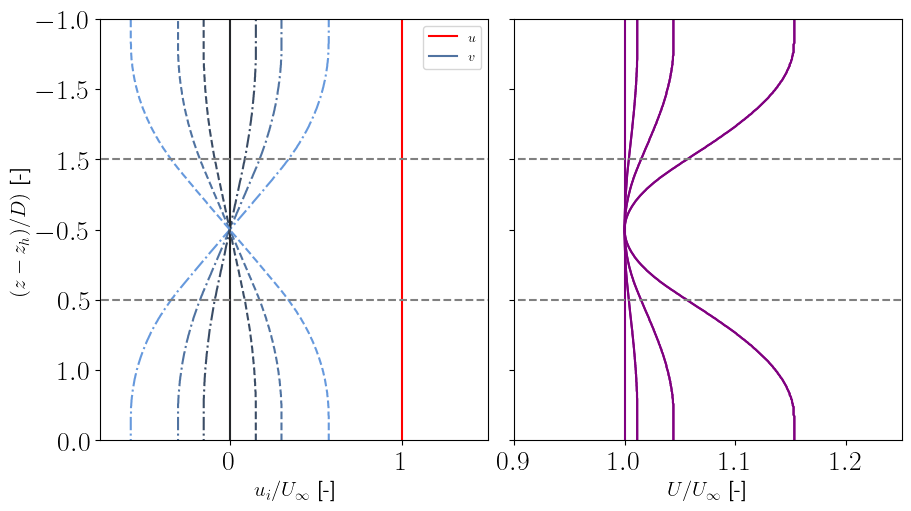

In [67]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(9, 5), constrained_layout=True, sharey=True)

subset_indices = np.array([55, 57, 58, 59, 60, 61, 63])

fontsize = 15

for i in range(len(subset_indices)):
    ax[0].plot(profiles[:,subset_indices[i]]/7,full_z,color=colors_v[i],linestyle=styles[i])

ax[0].plot(profiles_u[:,subset_indices[0]]/7,full_z,color='r',linestyle='-')

ax[0].plot([-10,-10],[1,1],color='r',linestyle='-',label='$u$')
ax[0].plot([-10,-10],[1,1],color=colors_v[5],linestyle='-',label='$v$')

for i in range(len(subset_indices)):
    ax[1].plot(np.sqrt(profiles[:,subset_indices[i]]**2 + profiles_u[:,subset_indices[i]]**2)/7,full_z,color='purple',linestyle='-')

ax[0].plot([-1,4],[477.5,477.5], '--', color = 'grey')
ax[0].plot([-1,4],[278.5,278.5], '--', color = 'grey')

ax[1].plot([-1,4],[477.5,477.5], '--', color = 'grey')
ax[1].plot([-1,4],[278.5,278.5], '--', color = 'grey')

ax[0].set_ylim([79.5,676.5])
ax[0].set_xlim([-0.75,1.5])
ax[1].set_xlim([0.9,1.25])

ax[0].legend()

vec = ticks = np.array([79.5, 179,278.5,378,477.5,577,676.5])

ax[0].set_yticks(vec)
ax[0].set_yticklabels({'$-1.5$','$-1.0$','$-0.5$','$0.0$','$0.5$','$1.0$','$1.5$'})

ax[0].set_ylabel('$(z-z_h)/D)$ [-]',fontsize=fontsize)
ax[0].set_xlabel('$u_i/U_{\infty}$ [-]',fontsize=fontsize)
ax[1].set_xlabel('$U/U_{\infty}$ [-]',fontsize=fontsize)


